# Compressing the repeated-interaction cooling cycle

Thermal-state preparation by **repeated interaction** (RI) cools a system by coupling it to a
small bath and resetting the bath, over and over. Each **cooling cycle** is a deep circuit —
**702 two-qubit gates** for a 3×4 lattice with one bath qubit at β=1 — and a full protocol needs
hundreds of cycles. That depth is the bottleneck on hardware.

This notebook asks two questions:

1. **How far can one cycle be compressed?**
2. **Does the cooling survive the compression?**

The answer to (2) is the interesting one, and it is *not* what you would guess from circuit
fidelity alone.

Everything here runs in seconds from pre-computed results in `data/`. The drivers that produced
them are in `scripts/` (they need `torch`; the reference protocol in `protocol/` needs
`cirq`+`qsimcirq`).

In [1]:
import sys, pathlib

# make `ricc` importable whether this notebook is run from examples/ or the repo root
_root = pathlib.Path.cwd()
if not (_root / "ricc").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
from ricc import plots as P

plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 9})

---
## 1. The object being compressed

Model: 2D transverse-field Ising, $H = J\sum_{\langle ij\rangle} X_iX_j - g\sum_i Z_i$.

One cooling cycle runs $2M_T+1$ fine Trotter slices; for each slice $j$:

| layer | operation |
|---|---|
| system | $e^{-i\delta J X_iX_j}$ on every bond, $e^{+i\delta g Z_i}$ on every site |
| bath | $e^{+i\delta h Z/2}$ on each bath qubit |
| coupling | $e^{-i\theta f[j]\delta\, A\otimes Y}$, with $A=(Z+Y)/\sqrt2$ and Gaussian envelope $f$ |

then **reset the bath** — which makes the whole cycle a CPTP *channel* on the system.
That reset is what makes §5 work.

In [2]:
d3, d4 = P.load("cc_trot_3x4.json"), P.load("cc_trot_4x4.json")
for d, name in ((d3, "3x4+1 (13 qubits)"), (d4, "4x4+1 (17 qubits)")):
    print(f"{name:22s}  {d['steps']:3d} slices x {d['Gg']:2d} 2q-gates/slice"
          f"  = {d['native']:4d} 2q-gates per cycle")
print(f"\nThe ideal (delta->0) cycle is the compression target;")
print(f"the native cycle's own error vs that ideal is {d3['eps_nat']:.3f}  <- the floor.")

3x4+1 (13 qubits)        39 slices x 18 2q-gates/slice  =  702 2q-gates per cycle
4x4+1 (17 qubits)        39 slices x 25 2q-gates/slice  =  975 2q-gates per cycle

The ideal (delta->0) cycle is the compression target;
the native cycle's own error vs that ideal is 0.012  <- the floor.


---
## 2. Baseline — how far does plain Trotter get you?

Replace the $2M_T+1$ fine slices with $k$ **coarse layers of the same gate set**, and measure the
channel infidelity to the ideal cycle. Then optionally **tune the angles** variationally instead of
using textbook Trotter values.

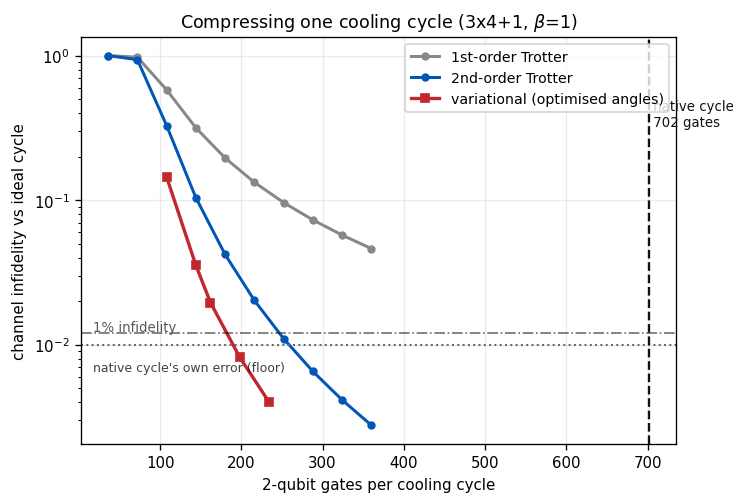

2q-gates to reach 1% infidelity   (native cycle = 702):
  1st-order Trotter : never (off-chart)
  2nd-order Trotter : 259   ->  2.7x fewer gates
  variational       : 190   ->  3.7x fewer gates  (1.36x beyond 2nd order)


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
res = P.plot_gatecount_vs_infidelity(ax)
plt.show()

print(f"2q-gates to reach 1% infidelity   (native cycle = {res['native']}):")
print(f"  1st-order Trotter : {'never (off-chart)' if res['t1'] != res['t1'] else round(res['t1'])}")
print(f"  2nd-order Trotter : {res['t2']:.0f}   ->  {res['native']/res['t2']:.1f}x fewer gates")
print(f"  variational       : {res['var']:.0f}   ->  {res['native']/res['var']:.1f}x fewer gates"
      f"  ({res['t2']/res['var']:.2f}x beyond 2nd order)")

**Read:** 1st-order never reaches 1% even at $k=20$ — it is effectively no compression.
2nd-order gets **2.7×**, and tuning the angles buys a further **1.35×**, for **3.7×** overall.

Note the curves flatten toward the native cycle's own error floor (dash-dot): you cannot compress
past the accuracy of the thing you are copying.

---
## 3. Why 2nd order is free here — and when it isn't

Going 1st → 2nd order usually costs extra gates. For the **Ising** cycle it costs **nothing**:
all the 2-body terms ($X_iX_j$) mutually commute, so the symmetric split only has to duplicate the
*single-qubit* field, which merges across steps. The 2-qubit layer stays one gate per bond.

The general rule, for $C$ mutually non-commuting 2-body colour classes (one class can always merge
across the step boundary):

$$\text{2q overhead} \;=\; \max\!\left(1,\ \frac{2C-2}{C}\right)$$

Verified below against exact ED for Heisenberg ($H=\sum XX+YY+ZZ$), where the terms do *not* commute.

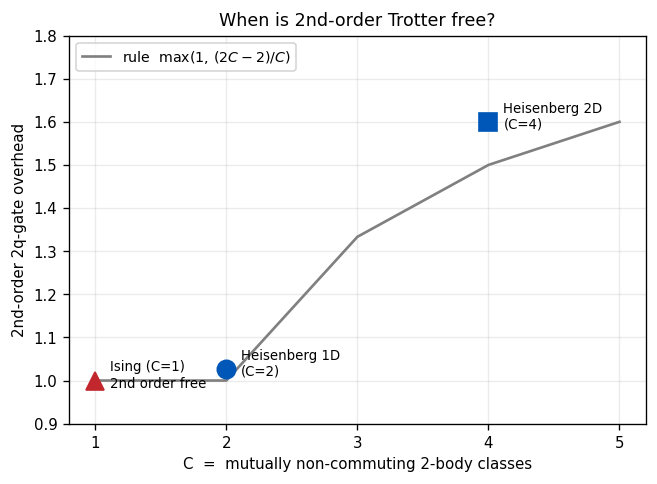

  C=1  measured overhead 1.00x   predicted 1.00x   (Ising (C=1))
  C=2  measured overhead 1.03x   predicted 1.00x   (Heisenberg 1D)
  C=4  measured overhead 1.60x   predicted 1.50x   (Heisenberg 2D)


In [4]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
meas = P.plot_trotter_order_rule(ax)
plt.show()

for C, ov, lab, _ in sorted(meas):
    print(f"  C={C}  measured overhead {ov:.2f}x   predicted {max(1,(2*C-2)/C):.2f}x   "
          f"({lab.splitlines()[0]})")

So the "2nd order is free" result is **specific to commuting 2-body terms** (Ising, and any 1D
chain where $C=2$). For 2D Heisenberg ($C=4$) it costs ~1.5×. It is still worth it — 2nd order is
far more accurate per gate — but the free lunch does not generalise.

---
## 4. Temperature dependence

Colder targets need longer cycles ($M_T$ grows with $\beta$), so the native gate count grows too.
Does the *compression* hold up?

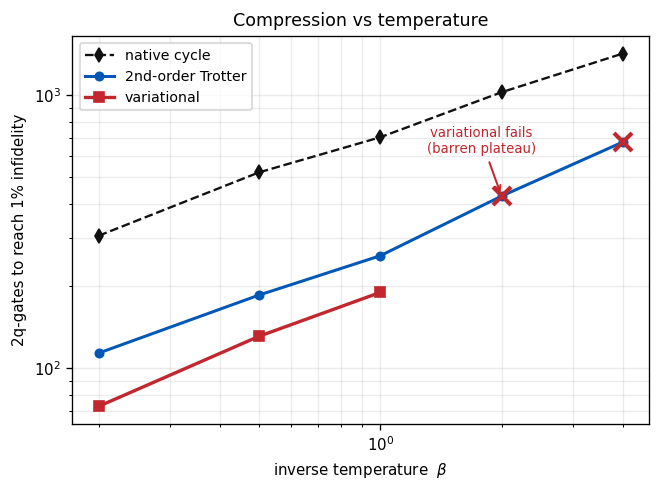

  beta   native   2nd-ord   variational
   0.2      306       114            73
   0.5      522       186           131
   1.0      702       258           190
   2.0     1026       427         FAILS
   4.0     1422       674         FAILS


In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
sweep = P.plot_beta_sweep(ax)
plt.show()

print(f"{'beta':>6} {'native':>8} {'2nd-ord':>9} {'variational':>13}")
for b, (n, t2, v) in sweep.items():
    vs = f"{v:.0f}" if v == v else "FAILS"
    print(f"{b:>6} {n:8d} {t2:9.0f} {vs:>13}")

**Read:** the 2nd-order compression ratio is **nearly β-independent** (2.7× at β=0.2 down to 2.1× at β=4, so it degrades only mildly as the
cycle grows). The *variational* step is not: past β≈2 the optimisation stops improving (its curve
becomes non-monotonic — more depth, worse fidelity), the signature of a **barren plateau**. At low
temperature, use 2nd-order Trotter and don't bother optimising.

---
## 5. The punchline — dissipation is a compression *asset*

Everything above compressed the cycle **unitary**. But cooling does not care about the unitary:
the cycle ends in a **bath reset + trace**, so what actually determines the steady state is the
**channel**. Many different unitaries realise the same channel — and a shallow ansatz can exploit
that freedom.

So: optimise the *channel* match instead, and then ask separately (a) how well the unitary matches,
and (b) whether the compressed cycle still cools to the Gibbs state.

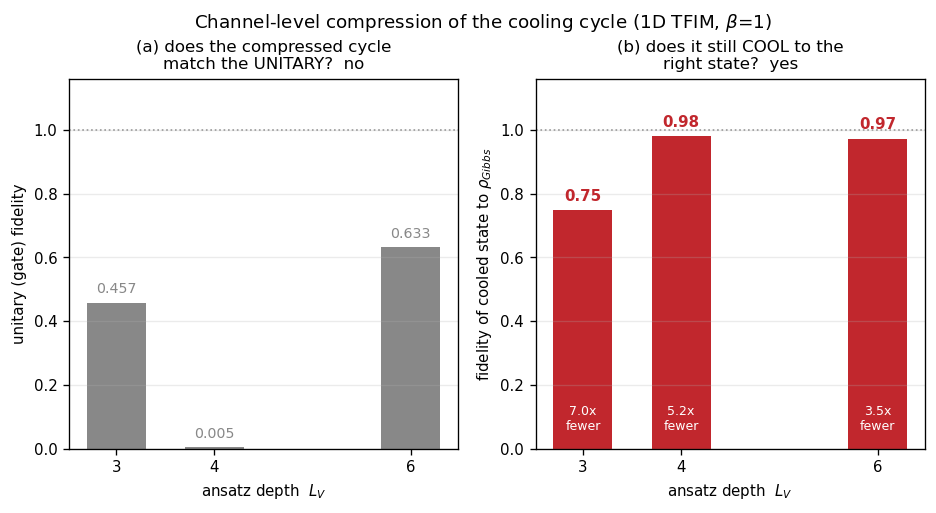

 L_V  unitary fid   Gibbs fid  gate reduction
   3       0.4574       0.748           7.00x
   4       0.0047       0.980           5.25x
   6       0.6327       0.973           3.50x


In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 4.0))
rows = P.plot_channel_vs_unitary(axL, axR, series="n3")
fig.suptitle("Channel-level compression of the cooling cycle (1D TFIM, "
             r"$\beta$=1)", fontsize=11, y=1.02)
plt.show()

print(f"{'L_V':>4} {'unitary fid':>12} {'Gibbs fid':>11} {'gate reduction':>15}")
for LV, fg, fgibbs, ratio in rows:
    print(f"{LV:>4} {fg:12.4f} {fgibbs:11.3f} {ratio:14.2f}x")

**This is the result.** At $L_V=4$ the compressed cycle has a unitary fidelity of **0.005** — that
is, it is essentially a *random* circuit as far as the unitary is concerned — yet it cools to the
Gibbs state at fidelity **0.98**, using **5.25× fewer** two-qubit gates.

Two consequences:

- **Optimise the channel, not the unitary.** Unitary fidelity is the wrong objective for a
  dissipative protocol; it massively over-constrains the problem.
- **There is an expressivity threshold.** $L_V=3$ is not enough (Gibbs fidelity 0.75); $L_V=4$ works.
  The threshold is sharp, so the useful compression sits just above it.

The per-cycle reduction is $(2M_T+1)/L_V$, **independent of system size**.

---
## 6. What this costs on hardware

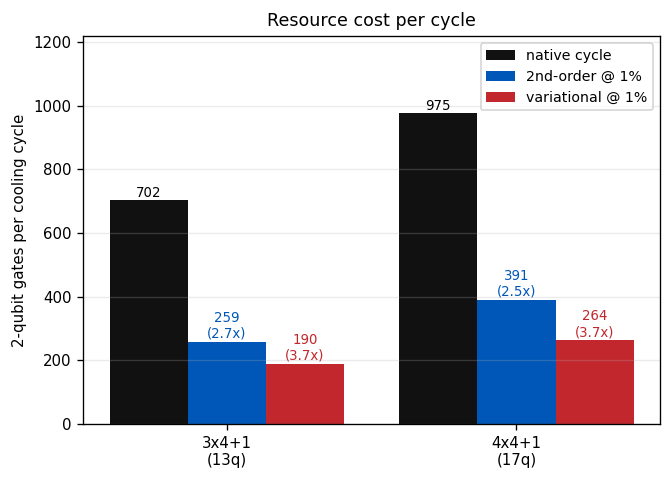

3x4+1 (13q)      native  702  ->  2nd-order   259 (2.7x)  ->  variational   190 (3.7x)
4x4+1 (17q)      native  975  ->  2nd-order   391 (2.5x)  ->  variational   264 (3.7x)

Channel-level (separate objective, 1D): 231 -> 44 gates/cycle = 5.25x,
and the ratio (2*M_T+1)/L_V does not depend on system size.


In [7]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
proj = P.plot_resource_projection(ax)
plt.show()

for lab, nat, t2, var in proj:
    print(f"{lab.replace(chr(10),' '):16s} native {nat:4d}  ->  2nd-order {t2:5.0f} "
          f"({nat/t2:.1f}x)  ->  variational {var:5.0f} ({nat/var:.1f}x)")
print("\nChannel-level (separate objective, 1D): 231 -> 44 gates/cycle = 5.25x,")
print("and the ratio (2*M_T+1)/L_V does not depend on system size.")

---
## 7. Caveats — what this does and does not show

- **Per-cycle depth only.** Compression shrinks the gates *within* a cycle. It does **not** reduce
  the *number* of cycles needed to reach the Gibbs state.
- **Dense/exact sizes.** The variational results are dense state-vector/ED, so 3×4+1 (13q) and
  4×4+1 (17q). Past ~17–21q the dense optimiser is too heavy; scaling needs the sampled-cost
  method (`scripts/`, and arXiv:2409.16346) or Pauli propagation.
- **The 5.25× channel result is a different objective on a different system** (1D, channel-match)
  from the 3.7× unitary result (2D, unitary-match). They are not the same number and should not be
  multiplied together.
- **β≥2 variational is barren-plateau limited** (§4), so the optimisation route is a
  high-temperature tool.

## Regenerating the data

```bash
cd scripts
python cc_trot_sweep.py 3 4 1.0     # 1st/2nd-order Trotter sweep      -> cc_trot_3x4.json
python cc_cycle_adam.py 3 4 1.0     # variational compression          -> cc_cycle_adam_3x4.json
python cc_heisenberg.py             # Heisenberg commutation check     -> cc_heisenberg.json
```
Copy the fresh JSONs into `data/` and re-run this notebook.